Тема работы: "Майнинг данных и полиноминальная регрессия".
В науке и разработке систем поддержки принятия решений (СППР) часто требуется моделировать зависимиости на основе набора данных. Методология работает с данными, определеяется стандартом CRISP_DM (Cross Industry Standard Proccess of Data Mining), что переводится как "Межотраслевой стандартный процесс майнинга данных" и объясняется как межотраслевой подход к анализу данных. Методология CRISP_DM показана на рисунке 1.


Рисунок 1 - Методология CRISP_DM и ее стабильность

CRISP_DM ялвяется адаптацией AGILE-подхода к анализу данных

In [ ]:
import pandas as pd

df = pd.read_csv('Ice_cream selling data.csv')
df.head()


,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


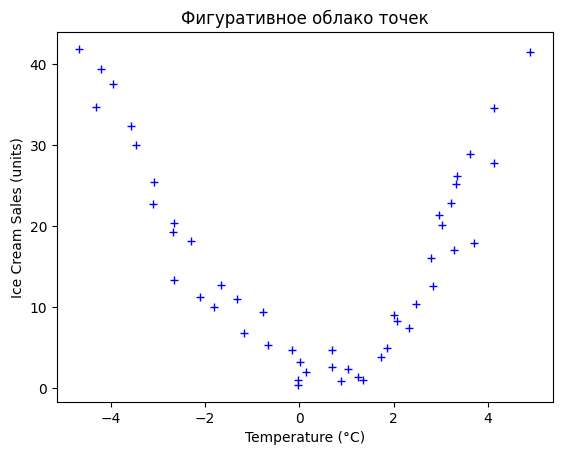

In [ ]:
from matplotlib import pyplot as plt

X = list(df['Temperature (°C)'])
Y = list(df['Ice Cream Sales (units)'])

plt.plot(X,Y,'b+')
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')
plt.title('Фигуративное облако точек')
plt.show()

Понимание данных в методологии CRISP_DM включает и сопровождается следующими действиями:
<ol>
  <li>Визуализация данных</li>
  <li>Поиск "выбросов" и аномалий (используется визуализация, анализ дисперсий, IsolationForests)</li>
  <li>Предварительная обработка данных, включая масштабирование (нормализация и стандартизация)</li>
</ol>

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, shuffle=True, test_size=0.2, random_state=42)
print('Количество записей в наборе для обучения', len(X_train))
print('Количество записей в наборе для тестирования', len(y_test))

print(X_train)
print(type(X_train))
print(type(X_train[1]))

Количество записей в наборе для обучения 39
Количество записей в наборе для тестирования 10
[-2.111869690297304, -3.578553716228682, 2.318591239633373, -2.672460827006454, -3.9496610890515704, -3.108440120890996, 3.211366144342004, 3.270044068238683, 4.130867961260749, -1.3263789834948423, -2.652286792936049, -1.1731232680778254, 0.6887809076106148, 2.075100596577272, 1.7400000122653545, -4.662262677220208, 3.3359324122355543, 1.999310369037285, -3.455711698065576, 1.3598126741393184, -2.288263998488389, 2.784836463321575, -4.316559446725467, -0.0338952855714465, -4.213984764590729, 2.8317602113138345, 2.4719459973351454, 0.1492445740467583, 3.020874314267157, -2.6514980333001317, 0.0086076987316141, -0.6737528018380357, 4.899031513688672, -0.0361564976826873, -3.081303324303456, 3.316072519311853, -1.6603477296372016, 1.2407116187783347, 2.959932091478899]
<class 'list'>
<class 'float'>


In [ ]:
# Задача. Дан список произвольных чисел. Создать список квадратов произвольных чисел.
numbers = [1, 20, 10, 5]

squares = [i**2 for i in numbers]
# for i in numbers:
#   squares.append(i**2)
print(squares)

[1, 400, 100, 25]


[ 1.87145125 -0.70641926  2.76830583]
X[0] -4.662262677220208


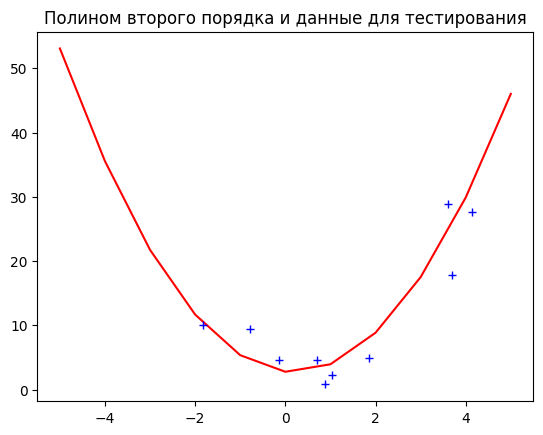

In [ ]:
import numpy as np

info = """
      Для моделирования используем функцию polyfit из библиотеки numpy
"""

coeff = np.polyfit(X_train, y_train, deg=2)
print(coeff)

def model_in_order(coeff,x_in):
  out = []
  powers = list(range(0,len(coeff)))[::-1]
  for c,p in zip(coeff,powers):
    out.append(c*x_in**p)
  return sum(out)


print('X[0]', X[0])


#модель
f_x = lambda x: coeff[0]*x**2 + coeff[1]*x + coeff[2]

X_model = list(range(-5,6))
y_model = [f_x(x) for x in X_model]
plt.plot(X_model, y_model, 'r-')
plt.plot(X_test, y_test, 'b+')
plt.title('Полином второго порядка и данные для тестирования')
plt.show()

In [ ]:
print("Вычисление метрик качества обучения для полинома 2 порядка")

coeff = np.polyfit(X_train, y_train, deg=2)
print(coeff)

def model_norder(coeff,x):
  summands = [c*x**p for c,p in zip(coeff,list(range(0,len(coeff))))]
  return sum(summands)

# def model_in_order(coeff,x_in):
#   out = []
#   powers = list(range(0,len(coeff)))[::-1]
#   for c,p in zip(coeff,powers):
#     out.append(c*x_in**p)
#   return sum(out)

#создаю набор y для тестовых значений X

ymodel = [model_in_order(coeff,xi) for xi in X_test]
print('ymodel', ymodel)
print('y_test', y_test)

delta_m = [((ym-yt)**2)**0.5 for ym,yt in zip(ymodel,y_test)]
# Относительная ошибка
relative_delta_m = [(((ym-yt)**2)**0.5)/yt for ym,yt in zip(ymodel,y_test)]
print('delta_m', delta_m)

#mean absoolute error
MAE = sum(delta_m)/len(delta_m)
print('MAE',MAE)

RelMSE= 100*sum(relative_delta_m)/len(relative_delta_m)
print('RelMSE',RelMSE,'%')

delta_m_rel = [100*(((ym-yt)**2)**0.5)/yt for ym,yt in zip(ymodel,y_test)]
print('delta_m_rel',delta_m_rel)



Вычисление метрик качества обучения для полинома 2 порядка
[ 1.87145125 -0.70641926  2.76830583]
ymodel [np.float64(10.244998524618623), np.float64(25.8280771409668), np.float64(31.824104104081513), np.float64(24.617042032254012), np.float64(4.43380256405445), np.float64(4.0078567162364465), np.float64(3.5827749143291907), np.float64(3.17865086523308), np.float64(7.869904520486553), np.float64(2.915913684753998)]
y_test [10.012867848328883, 17.84395651991352, 27.69838334813044, 28.912187929191944, 9.392968661109096, 2.313806358173546, 0.7899736505077737, 4.625689457527259, 4.857987801146915, 4.673642540546473]
delta_m [np.float64(0.23213067628974038), np.float64(7.9841206210532825), np.float64(4.125720755951072), np.float64(4.295145896937932), np.float64(4.959166097054646), np.float64(1.6940503580629005), np.float64(2.792801263821417), np.float64(1.447038592294179), np.float64(3.011916719339639), np.float64(1.7577288557924753)]
MAE 3.229981983659728
RelMSE 68.72471496082025 %
delta_m_r

In [ ]:
#A/B тестирование
